In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from uncertainties import ufloat
from uncertainties import unumpy as unp

from scipy.optimize import curve_fit

In [69]:
l_mm = 28.0
lam_m = 523e-9   # Wellenlänge in Metern
u_x_mm = 0.1     # Ablesefehler in mm
u_N = 0.50       # Unsicherheit der Maxima

df = pd.read_excel("data/Book1.xlsx")
df = df[df.columns[0:2]]
df.dropna(inplace=True)

df.columns = ["N", "x_mm"]
df["N"] = df["N"].astype(int).abs()
df["x_mm"] = df["x_mm"].astype(float)

df["N_u"] = unp.uarray(df["N"], u_N)
df["x_u_mm"] = unp.uarray(df["x_mm"], u_x_mm)

# Formel: delta_s = N * lambda
df["delta_s_u_um"] = df["N_u"] * (lam_m * 1e6) 
df["delta_s_um"] = unp.nominal_values(df["delta_s_u_um"])
df["u_delta_s_um"] = unp.std_devs(df["delta_s_u_um"])

df["alpha_u_rad"] = unp.arctan(df["x_u_mm"] / l_mm)
df["alpha_deg"] = unp.nominal_values(unp.degrees(df["alpha_u_rad"]))
df["u_alpha_deg"] = unp.std_devs(unp.degrees(df["alpha_u_rad"]))

df.head()

,N,x_mm,N_u,x_u_mm,delta_s_u_um,delta_s_um,u_delta_s_um,alpha_u_rad,alpha_deg,u_alpha_deg
1,1,3.45,1.0+/-0.5,3.45+/-0.10,0.52+/-0.26,0.523,0.2615,0.1226+/-0.0035,7.024254,0.201568
2,2,3.12,2.0+/-0.5,3.12+/-0.10,1.05+/-0.26,1.046,0.2615,0.1110+/-0.0035,6.358158,0.202118
3,3,3.01,3.0+/-0.5,3.01+/-0.10,1.57+/-0.26,1.569,0.2615,0.1071+/-0.0035,6.135733,0.202290
4,6,2.62,6.0+/-0.5,2.62+/-0.10,3.14+/-0.26,3.138,0.2615,0.0933+/-0.0035,5.345683,0.202852
5,9,2.40,9.0+/-0.5,2.40+/-0.10,4.71+/-0.26,4.707,0.2615,0.0855+/-0.0035,4.899092,0.203135


In [76]:
h = 5.0e-3
u_h = 0.01e-3

def model(alpha_deg, n, alpha0):
    # Relativer Winkel zur Senkrechten in Radiant
    # np.abs stellt sicher, dass die Drehung symmetrisch behandelt wird
    phi_rad = np.radians(np.abs(alpha_deg - alpha0))
    
    term1 = np.sqrt(n**2 - np.sin(phi_rad)**2)
    term2 = np.cos(phi_rad)
    term3 = (1 - n)
    
    delta_s = 2 * h * (term1 - term2 + term3)
    return delta_s / lam_m

x_data_deg = df["alpha_deg"].values
y_data = df["N"].values

# Fit durchführen
popt, pcov = curve_fit(model, x_data_deg, y_data, p0=[1.49, 0.0], sigma=np.ones_like(y_data)*0.5)

# Alle Standardabweichungen der Fit-Parameter auf einmal berechnen
perr = np.sqrt(np.diag(pcov))

n_fit, alpha0_fit = popt
n_err_stat = perr[0]    # Statistischer Fehler von n
alpha0_err = perr[1]    # Fehler von alpha0

# Systematischer Fehler für n (wegen der Unsicherheit der Dicke h)
n_err_sys = (n_fit - 1) * (u_h / h)
n_err_total = np.sqrt(n_err_stat**2 + n_err_sys**2)

print(f"Ergebnis:  n = {n_fit:.4f} +/- {n_err_total:.4f}")
print(f"Nullpunkt: alpha0 = {alpha0_fit:.3f}° +/- {alpha0_err:.3f}°")

Ergebnis:  n = 1.4484 +/- 0.0059
Nullpunkt: alpha0 = 8.044° +/- 0.018°


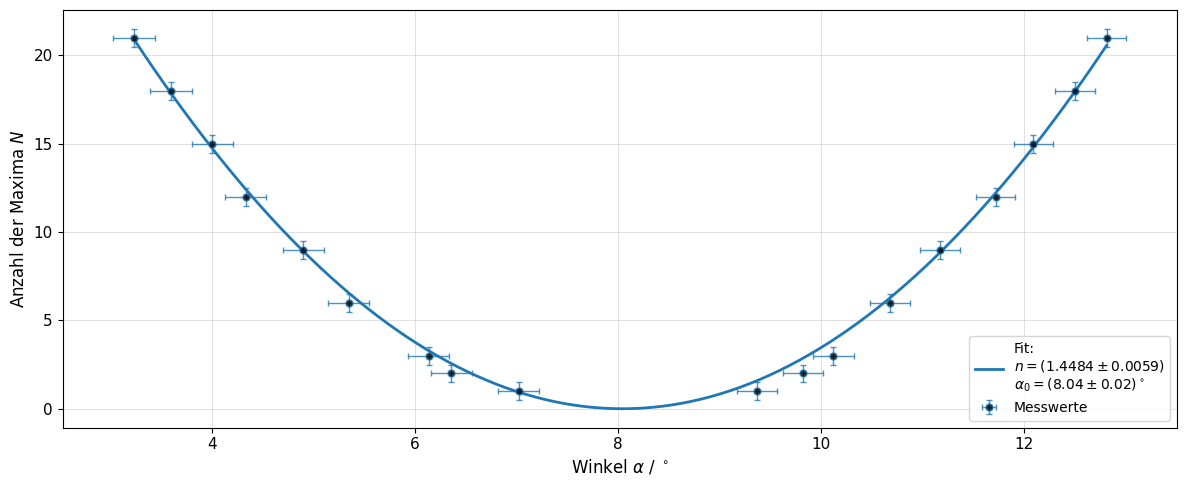

In [80]:
# 1. Plot-Einstellungen
plt.figure(figsize=(12, 5))
plt.rcParams['font.size'] = 11

# 2. Datenpunkte mit Errorbars
plt.errorbar(df['alpha_deg'], df['N'], 
             xerr=df['u_alpha_deg'], 
             yerr=0.5, 
             fmt='o', mfc='black', mec='C0', markersize=5,
             ecolor='C0', elinewidth=1, capsize=2, 
             label='Messwerte', alpha=0.8)

# 3. Fit-Kurve und dynamische Legende
alpha_range = np.linspace(df['alpha_deg'].min(), df['alpha_deg'].max(), 200)

# Hier nutzen wir n_err_total (stat + sys) und alpha0_err (stat)
fit_label = (f"Fit:\n"
             f"$n = ({n_fit:.4f} \\pm {n_err_total:.4f})$\n"
             f"$\\alpha_0 = ({alpha0_fit:.2f} \\pm {alpha0_err:.2f})^\\circ$")

plt.plot(alpha_range, model(alpha_range, *popt), 
         color='C0', linestyle='-', linewidth=2, label=fit_label)

# 4. Achsenbeschriftung und Design
plt.xlabel(r'Winkel $\alpha$ / $^\circ$', fontsize=12)
plt.ylabel('Anzahl der Maxima $N$', fontsize=12)

# Gitter und Rahmen
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='lightgray')
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Legende positionieren
plt.legend(frameon=True, loc='lower right', fontsize=10)
plt.tight_layout()

plt.show()